## Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

#Task 1: Data Understanding and Visualization:

##1.1 Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

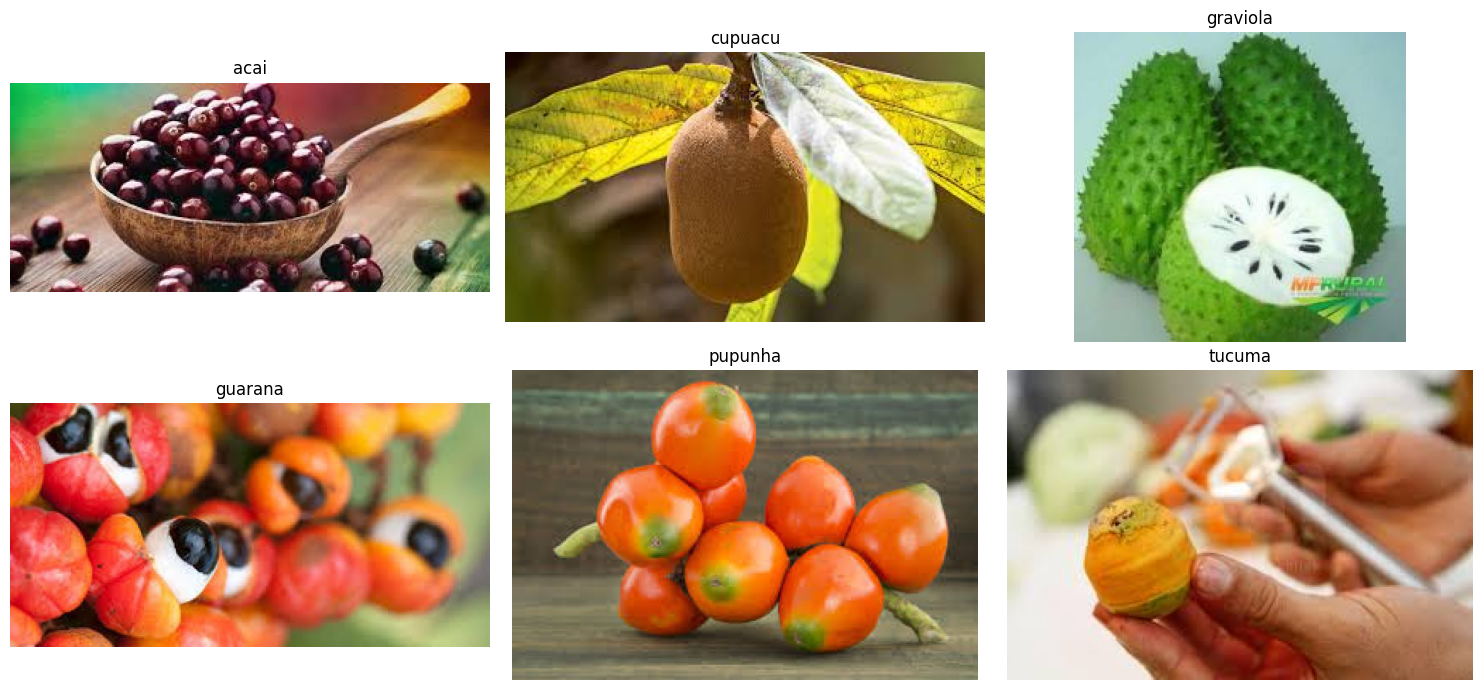

In [37]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

#load dataset
train_dir = "/content/drive/MyDrive/AI and ML/Workshop and worksheets/Week 5/FruitinAmazon/train"

# Get the list of class directories
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Setup the figure for a grid with two rows
cols = (num_classes + 1) // 2
plt.figure(figsize=(15, 7))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    # Get all images in the class directory
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Select one image randomly
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    # Load and display
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [38]:
corrupted_images = []
# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Attempt to open and verify the image
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                # If corrupted, remove and log
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}") [cite: 493]

if not corrupted_images:
  print("No Corrupted Images Found.")
else:
  print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [23]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with

In [25]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

#Task 4: Compile the Model

In [28]:
# Task 4: Compilation and Training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_fruit_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8032 - loss: 0.6258

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 740ms/step - accuracy: 0.7222 - loss: 0.8772 - val_accuracy: 0.8889 - val_loss: 0.1538
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 570ms/step - accuracy: 0.7778 - loss: 0.9217 - val_accuracy: 0.9444 - val_loss: 0.2139
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 915ms/step - accuracy: 0.8611 - loss: 0.4183 - val_accuracy: 0.7778 - val_loss: 0.4315
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 557ms/step - accuracy: 0.9861 - loss: 0.2133 - val_accuracy: 0.8333 - val_loss: 0.5502
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 1.0000 - loss: 0.2090 - val_accuracy: 0.8333 - val_loss: 0.6152
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 570ms/step - accuracy: 0.9861 - loss: 0.2044 - val_accuracy: 0.8333 - val_loss: 0.5271
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 566ms/step - accuracy: 1.0000 - loss: 0.1388 - val_accuracy: 0.8333 - val_loss: 0.3974
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 687ms/step - accuracy: 1.0000 - loss: 0.0584 - val_accuracy: 0.8333 - val_loss: 0.2

#Task 5 -Evaluate the model


In [29]:
# Task 5: Evaluation
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8889 - loss: 0.1538
Validation Accuracy: 0.8889


#Task 6: Save and Load the Model

In [32]:
import numpy as np
from sklearn.metrics import classification_report

# Task 6: Save and Load
model.save('final_model.h5')
new_model = tf.keras.models.load_model('final_model.h5')

# Task 7: Predictions and Report

In [35]:
# Task 7: Predictions and Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = new_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
              precision    recall  f1-score   support

           4       0.67      0.67      0.67         3
           5       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.80      0.80      0.80        18
weighted avg       0.89      0.89      0.89        18

